In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats

df = pd.read_csv("../data/synthetic_tensile.csv")
df.head()

,H_conc_ppm,RA_percent,data_type
0,0.0,60.61,synthetic
1,0.0,57.92,synthetic
2,0.0,61.50,synthetic
3,0.0,61.88,synthetic
4,0.0,56.10,synthetic


In [2]:
print(df.describe())
print("Missing values:", df.isna().sum().sum())

       H_conc_ppm  RA_percent
count   40.000000    40.00000
mean     3.562500    27.68300
std      3.334335    20.40919
min      0.000000     0.13000
25%      0.875000     9.65500
50%      2.500000    25.66000
75%      5.500000    45.34500
max     10.000000    61.88000
Missing values: 0


In [3]:
summary = df.groupby("H_conc_ppm")["RA_percent"].agg(["mean", "std", "count"]).reset_index()
summary["sem"] = summary["std"] / np.sqrt(summary["count"])
summary

,H_conc_ppm,mean,std,count,sem
0,0.0,59.602,2.495039,5,1.115815
1,0.5,49.420,1.193461,5,0.533732
2,1.0,43.610,0.820792,5,0.367069
3,2.0,29.548,1.575808,5,0.704723
4,3.0,20.906,1.479774,5,0.661775
5,5.0,10.982,0.715730,5,0.320084
6,7.0,5.586,2.418539,5,1.081603
7,10.0,1.810,1.760355,5,0.787255


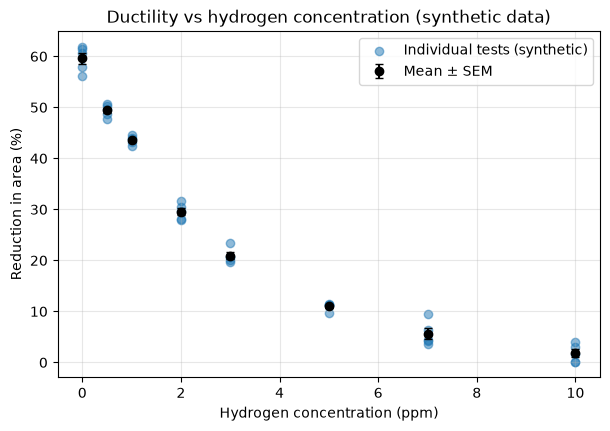

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(df["H_conc_ppm"], df["RA_percent"], alpha=0.5, label="Individual tests (synthetic)")
ax.errorbar(summary["H_conc_ppm"], summary["mean"], yerr=summary["sem"],
            fmt="o", color="black", capsize=3, label="Mean ± SEM")
ax.set_xlabel("Hydrogen concentration (ppm)")
ax.set_ylabel("Reduction in area (%)")
ax.set_title("Ductility vs hydrogen concentration (synthetic data)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [5]:
RA_air = df.loc[df["H_conc_ppm"] == 0, "RA_percent"].mean()
df["EI"] = (RA_air - df["RA_percent"]) / RA_air
print(f"Uncharged reduction in area: {RA_air:.1f} %")
df.groupby("H_conc_ppm")["EI"].mean()

Uncharged reduction in area: 59.6 %


H_conc_ppm
0.0    -7.216450e-17
0.5     1.708332e-01
1.0     2.683131e-01
2.0     5.042448e-01
3.0     6.492400e-01
5.0     8.157444e-01
7.0     9.062783e-01
10.0    9.696319e-01
Name: EI, dtype: float64

In [6]:
def exp_model(C, RA0, k):
    return RA0 * np.exp(-k * C)

x = df["H_conc_ppm"].values
y = df["RA_percent"].values

popt, pcov = curve_fit(exp_model, x, y, p0=[50, 0.1])
perr = np.sqrt(np.diag(pcov))                 # standard errors
dof = len(x) - len(popt)
tcrit = stats.t.ppf(0.975, dof)               # for 95% confidence

for name, val, err in zip(["RA0", "k"], popt, perr):
    print(f"{name} = {val:.3f} ± {tcrit*err:.3f}  (95% CI)")

RA0 = 59.569 ± 1.150  (95% CI)
k = 0.343 ± 0.015  (95% CI)


In [7]:
TRUE_RA0, TRUE_K = 60.0, 0.35
for name, val, err, true in zip(["RA0", "k"], popt, perr, [TRUE_RA0, TRUE_K]):
    lo, hi = val - tcrit*err, val + tcrit*err
    print(f"{name}: true = {true}, fitted CI = [{lo:.3f}, {hi:.3f}], "
          f"recovered: {lo <= true <= hi}")

RA0: true = 60.0, fitted CI = [58.419, 60.719], recovered: True
k: true = 0.35, fitted CI = [0.327, 0.358], recovered: True


In [8]:
def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

lin = stats.linregress(x, y)
r2_lin = r_squared(y, lin.intercept + lin.slope * x)
r2_exp = r_squared(y, exp_model(x, *popt))
print(f"Linear fit R² = {r2_lin:.3f}")
print(f"Exponential fit R² = {r2_exp:.3f}")

Linear fit R² = 0.841
Exponential fit R² = 0.994


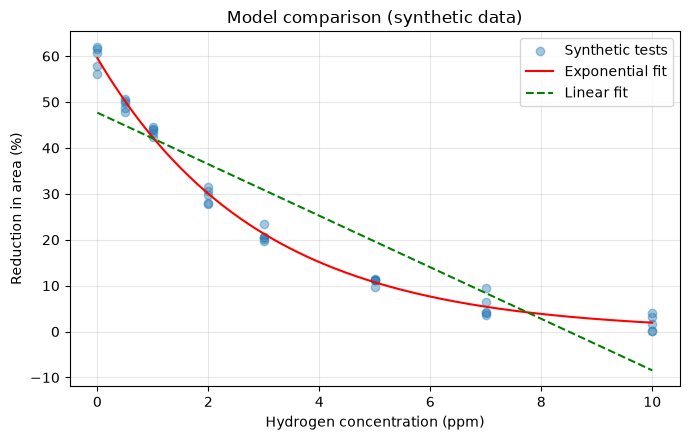

In [9]:
xs = np.linspace(0, 10, 200)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(x, y, alpha=0.4, label="Synthetic tests")
ax.plot(xs, exp_model(xs, *popt), "r-", label="Exponential fit")
ax.plot(xs, lin.intercept + lin.slope * xs, "g--", label="Linear fit")
ax.set_xlabel("Hydrogen concentration (ppm)")
ax.set_ylabel("Reduction in area (%)")
ax.set_title("Model comparison (synthetic data)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../figures/ductility_fit.png", dpi=300)
plt.show()

In [10]:
uncharged = df.loc[df["H_conc_ppm"] == 0, "RA_percent"]
charged = df.loc[df["H_conc_ppm"] == 10, "RA_percent"]
t_stat, p_val = stats.ttest_ind(uncharged, charged, equal_var=False)
print(f"t = {t_stat:.2f}, p = {p_val:.2e}")

t = 42.32, p = 6.86e-10
